In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import invwishart
import jax
import jax.numpy as jnp
from scipy.optimize import minimize
import time

# --------------------------------------------------------
# 0. Setting up the environment and importing necessary libraries
# --------------------------------------------------------
# This script implements the penalty function approach (Algorithm 1) 
# by Uhlig (2005) to identify structural shocks in a VAR model.
#
# ENGINEERING NOTE: Optimization Backend
# Unlike pure sign restrictions which rely on random draws and logical masks, 
# the penalty function approach requires solving a numerical optimization problem. 
# We utilize JAX (Just-In-Time compilation and Autograd) to handle the heavy 
# multidimensional tensor calculus and gradient-based optimizations efficiently.
#
# Note: Ensure 'uhligdata.xls' is in the current working directory.

# ==========================================
# 1. DATA PREPARATION FOR THE LOCAL ENVIRONMENT
# ==========================================
# Load dataset and drop NA values to ensure a balanced panel.
filepath = 'uhligdata.xls'
df = pd.read_excel(filepath).dropna()

# --------------------------------------------------------
# Log-transformations
# --------------------------------------------------------
# We apply a log-transformation (* 100) to non-stationary level variables.
# Following Uhlig (2005, p. 392) and standard macroeconomic convention, the 
# federal funds rate (FEDFUNDS) is strictly EXCLUDED from this transformation, 
# as it is already expressed in percentage terms.
cols_to_log = ['GDPC1', 'GDPDEF', 'CPRINDEX', 'BOGNONBR', 'TOTRESNS']
for col in cols_to_log:
    df[col] = np.log(df[col]) * 100

# Define the variable ordering according to the baseline model and extract the raw array.
ordered_cols = ['GDPC1', 'GDPDEF', 'CPRINDEX', 'FEDFUNDS', 'BOGNONBR', 'TOTRESNS']
Y_raw = df[ordered_cols].values

# --------------------------------------------------------
# Constructing the VAR Design Matrix (X) and Dependent Variable (Y)
# --------------------------------------------------------
# We set the lag order p = 12 (standard for monthly macroeconomic data).
p = 12
T_raw, m = Y_raw.shape

# ENGINEERING NOTE: Dimension Management
# T is the effective sample size. We inherently lose the first p observations 
# to construct the historical lag structure.
T = T_raw - p  

# Y contains the dependent variables. By slicing [p:], we align it starting 
# strictly from the (p+1)-th observation.
Y = Y_raw[p:]

# Pre-allocate the design matrix (X) with zeros. 
# Dimensions are T (usable periods) by m*p (all lags for all variables).
X = np.zeros((T, m * p))

# ENGINEERING NOTE: Populating the Lag Matrix Block by Block
# The loop populates X iteratively for each lag 'i'. 
# - The columns: 'i*m : (i+1)*m' allocates a block of m columns for the i-th lag.
# - The rows: 'p - i - 1 : T_raw - i - 1' steps back in the Y_raw array to fetch 
#   the exact historical window for that specific lag, perfectly aligning the 
#   explanatory variables with the current period in Y.
for i in range(p):
    X[:, i*m : (i+1)*m] = Y_raw[p - i - 1 : T_raw - i - 1]

# Append a column of ones to the right side of X to account for the VAR intercept.
X = np.hstack([X, np.ones((T, 1))])

In [10]:
# ==========================================
# 1.5 STANDARD DEVIATIONS FOR NORMALIZATION
# ==========================================
# ENGINEERING NOTE: Scale Normalization ("Apples to Apples")
# Uhlig (2005, pp. 413-414) emphasizes that the penalty function sums deviations 
# across different variables. To prevent variables with inherently larger variances 
# from dominating the objective function, we normalize the candidate IRFs by the 
# standard deviations of their respective first differences.
sigma = np.std(np.diff(Y_raw, axis=0), axis=0)


# ==========================================
# 2. PENALTY FUNCTION (JAX IMPLEMENTATION)
# ==========================================
# We JIT-compile this penalty objective for lightning-fast, C-level execution.
# The optimizer will iteratively modify the vector 'alpha' to minimize this loss.

@jax.jit
def penalty_objective(alpha, irf_base_K, sigma_jax):
    """
    Computes the asymmetric penalty loss for a candidate structural shock.
    
    ARGUMENTS:
    alpha: A random m-dimensional vector (modified by the optimizer).
    irf_base_K: Pre-computed Cholesky IRFs for the restriction horizon (K=6). Shape: (6, m, m).
    sigma_jax: Standard deviation vector for normalization.
    """
    
    # ENGINEERING NOTE: Implicit Unit Sphere Constraint
    # By normalizing 'alpha' strictly INSIDE the objective function, we mathematically 
    # guarantee that the resulting vector always lies on the unit hypersphere. 
    # This elegant trick replaces Uhlig's complex polar coordinate parameterization 
    # and allows us to use fast, unconstrained optimization algorithms.
    alpha_norm = alpha / jnp.linalg.norm(alpha)
    
    # Compute the candidate impulse response over the K=6 horizon in a single dot product.
    # Resulting shape: (6, m) matrix containing the IRFs for all variables.
    candidate_irf = jnp.dot(irf_base_K, alpha_norm)
    
    # ENGINEERING NOTE: Extracting and Normalizing Restricted Variables
    # We slice out the 4 variables subject to sign restrictions (indices 1, 2, 3, 4).
    # Following Uhlig (2005), we standardize them. 
    # CRITICAL: For the Federal Funds Rate (index 3), we expect a positive response (>=0). 
    # To map this into a uniform "negative is good" penalty logic, we reverse its sign (l_j = -1).
    x1 =  candidate_irf[:, 1] / sigma_jax[1]  # GDP Deflator (Target: <= 0)
    x2 =  candidate_irf[:, 2] / sigma_jax[2]  # Comm. Price Index (Target: <= 0)
    x3 = -candidate_irf[:, 3] / sigma_jax[3]  # Fed Funds Rate (Target: >= 0 -> Reversed to <= 0)
    x4 =  candidate_irf[:, 4] / sigma_jax[4]  # Non-borrowed Reserves (Target: <= 0)
    
    # Concatenate into a single 24-dimensional flat vector (4 variables x 6 periods)
    x = jnp.concatenate([x1, x2, x3, x4])
    
    # ENGINEERING NOTE: Uhlig's Asymmetric Penalty Formulation
    # If x <= 0: The restriction holds. We assign a minor penalty: f(x) = x
    # If x >  0: The restriction is violated. We assign a severe penalty: f(x) = 100 * x
    # jnp.where vectorizes this piecewise evaluation instantly across all 24 elements.
    penalties = jnp.where(x <= 0, x, 100.0 * x)
    
    # Return the double sum of penalties (across all restricted variables and periods)
    return jnp.sum(penalties)

# ENGINEERING NOTE: Reverse-Mode Autodiff Magic
# We use jax.value_and_grad to return BOTH the objective value and its exact, 
# analytically computed gradient vector with respect to 'alpha'. 
# This eliminates the need for slow, numerical finite-difference gradient approximations.
loss_and_grad = jax.jit(jax.value_and_grad(penalty_objective))

In [11]:
# ==========================================
# 3. REDUCED-FORM VAR AND POSTERIOR PARAMETERS
# ==========================================
# We estimate the reduced-form VAR (OLS) and compute the exact scale matrix 
# for the Inverse Wishart posterior distribution.

XX = X.T @ X
XX_inv = np.linalg.inv(XX)
XX_inv = (XX_inv + XX_inv.T) / 2.0  # Enforce perfect symmetry for Wishart stability

# ENGINEERING NOTE: Flat Prior and OLS Equivalency
# In this Bayesian VAR framework, assuming a non-informative (flat) prior and 
# homoskedastic errors allows the posterior mean of the VAR coefficients to 
# analytically collapse to the standard OLS estimator (B_hat).
B_hat = XX_inv @ X.T @ Y
U = Y - X @ B_hat

# ENGINEERING NOTE: Inverse Wishart Scale Matrix
# S_scale is the unscaled covariance matrix of the OLS residuals (U^T U).
# It serves as the scale parameter for drawing the true covariance matrix (Omega) 
# in the Monte Carlo simulation. We explicitly average it with its transpose 
# to guarantee the strict symmetry required by the Inverse Wishart distribution.
S_scale = U.T @ U
S_scale = (S_scale + S_scale.T) / 2.0

In [12]:
# --------------------------------------------------------
# 4. PENALTY FUNCTION OPTIMIZATION (JAX + SciPy BFGS)
# --------------------------------------------------------

n_keep = 1000
n_steps = 60

valid_irfs_penalty = []
valid_fevds_penalty = []

print("Starting penalty function optimization (JAX + SciPy BFGS)...")
start_time = time.time()

# -----------------------------------------------------------------------------
# 4.1. Cholesky decomposition of XX_inv
# -----------------------------------------------------------------------------
# ENGINEERING NOTE: Minimal Jitter
# Applied OUTSIDE the loop to prevent repeated singular matrix errors during parameter draws.
try:
    chol_XX_inv = np.linalg.cholesky(XX_inv)
except np.linalg.LinAlgError:
    chol_XX_inv = np.linalg.cholesky(XX_inv + np.eye(XX_inv.shape[0]) * 1e-9)

draw_count = 0
successful_opts = 0

while successful_opts < n_keep:
    draw_count += 1
    
    # -------------------------------------
    # 1. Posterior draws (Sigma and B)
    # -------------------------------------
    Omega_draw = invwishart.rvs(df=T, scale=S_scale)

    try:
        chol_Omega = np.linalg.cholesky(Omega_draw)
    except np.linalg.LinAlgError:
        chol_Omega = np.linalg.cholesky(Omega_draw + np.eye(m) * 1e-9)
    
    Z_B = np.random.randn(X.shape[1], m)
    B_draw = B_hat + chol_XX_inv @ Z_B @ chol_Omega.T
    
    # -----------------------------------------------------
    # 2. Companion form and Base IRFs
    # -----------------------------------------------------
    B_ar = B_draw[:-1, :]
    Gamma = np.zeros((m * p, m * p))
    Gamma[:m, :] = B_ar.T
    Gamma[m:, :-m] = np.eye(m * (p - 1))
    
    J = np.zeros((m, m * p))
    J[:m, :m] = np.eye(m)
    
    irf_base = np.zeros((n_steps, m, m))
    carry = np.eye(m * p)
    for k in range(n_steps):
        irf_base[k] = J @ carry @ J.T @ chol_Omega
        carry = carry @ Gamma
        
    # Extract the restriction horizon (K=6) and convert to JAX array for the optimizer
    irf_base_K = jnp.array(irf_base[:6, :, :])
    
    # ------------------------------------------------------
    # 3. Optimization (SciPy BFGS + JAX Autodiff)
    # ------------------------------------------------------
    best_penalty = np.inf
    best_alpha = None
    
    # ENGINEERING NOTE: Avoiding Local Minima
    # The penalty surface can be non-convex depending on the parameter draw.
    # We initiate the BFGS optimizer from 2 distinct, random starting points on 
    # the unit sphere to increase the probability of finding the global minimum.
    for _ in range(2):
        alpha_init = np.random.randn(m)
        alpha_init = alpha_init / np.linalg.norm(alpha_init)
        
        # 'jac=True' explicitly commands SciPy to utilize our JAX-computed analytical gradients
        res = minimize(loss_and_grad, alpha_init, args=(irf_base_K, sigma), 
                       method='BFGS', jac=True, options={'maxiter': 100})
        
        if res.success and res.fun < best_penalty:
            best_penalty = res.fun
            best_alpha = res.x
            
    # -------------------------------------------------------------------
    # 4. Finalizing IRF and FEVD computations
    # -------------------------------------------------------------------
    if best_alpha is not None:
        
        # ENGINEERING NOTE: The "Scale-Invariant Optimizer" Trap
        # Because our JAX penalty_objective internally normalizes 'alpha', the objective 
        # is strictly scale-invariant. Consequently, the unconstrained BFGS algorithm 
        # may wander off the unit sphere along a flat gradient ray. 
        # We MUST re-normalize best_alpha to ensure it is a valid unit vector before 
        # calculating the final macroeconomic responses.
        best_alpha = best_alpha / np.linalg.norm(best_alpha)
        
        # Multiply the full 60-month base IRF by the optimized direction vector
        optimal_irf = irf_base @ best_alpha
        
        # Calculate FEVD (Cumulative variance of shock vs. Total forecast error variance)
        var_identified = np.cumsum(optimal_irf**2, axis=0)
        var_total = np.cumsum(np.sum(irf_base**2, axis=2), axis=0)
        fevd = (var_identified / var_total) * 100
        
        valid_irfs_penalty.append(optimal_irf)
        valid_fevds_penalty.append(fevd)
        successful_opts += 1
        
        if successful_opts % 100 == 0:
            print(f"Collected: {successful_opts} / {n_keep} (elapsed time: {time.time() - start_time:.2f} seconds)")

print(f"\nOptimization complete! {successful_opts} successful paths yielded from {draw_count} posterior draws.")
print(f"Total run time: {time.time() - start_time:.2f} seconds.")

Starting penalty function optimization (JAX + SciPy BFGS)...
Collected: 100 / 1000 (elapsed time: 31.47 seconds)
Collected: 200 / 1000 (elapsed time: 65.51 seconds)
Collected: 300 / 1000 (elapsed time: 88.97 seconds)
Collected: 400 / 1000 (elapsed time: 110.99 seconds)
Collected: 500 / 1000 (elapsed time: 133.40 seconds)
Collected: 600 / 1000 (elapsed time: 158.52 seconds)
Collected: 700 / 1000 (elapsed time: 181.49 seconds)
Collected: 800 / 1000 (elapsed time: 210.45 seconds)
Collected: 900 / 1000 (elapsed time: 234.72 seconds)
Collected: 1000 / 1000 (elapsed time: 251.49 seconds)

Optimization complete! 1000 successful paths yielded from 6048 posterior draws.
Total run time: 251.49 seconds.


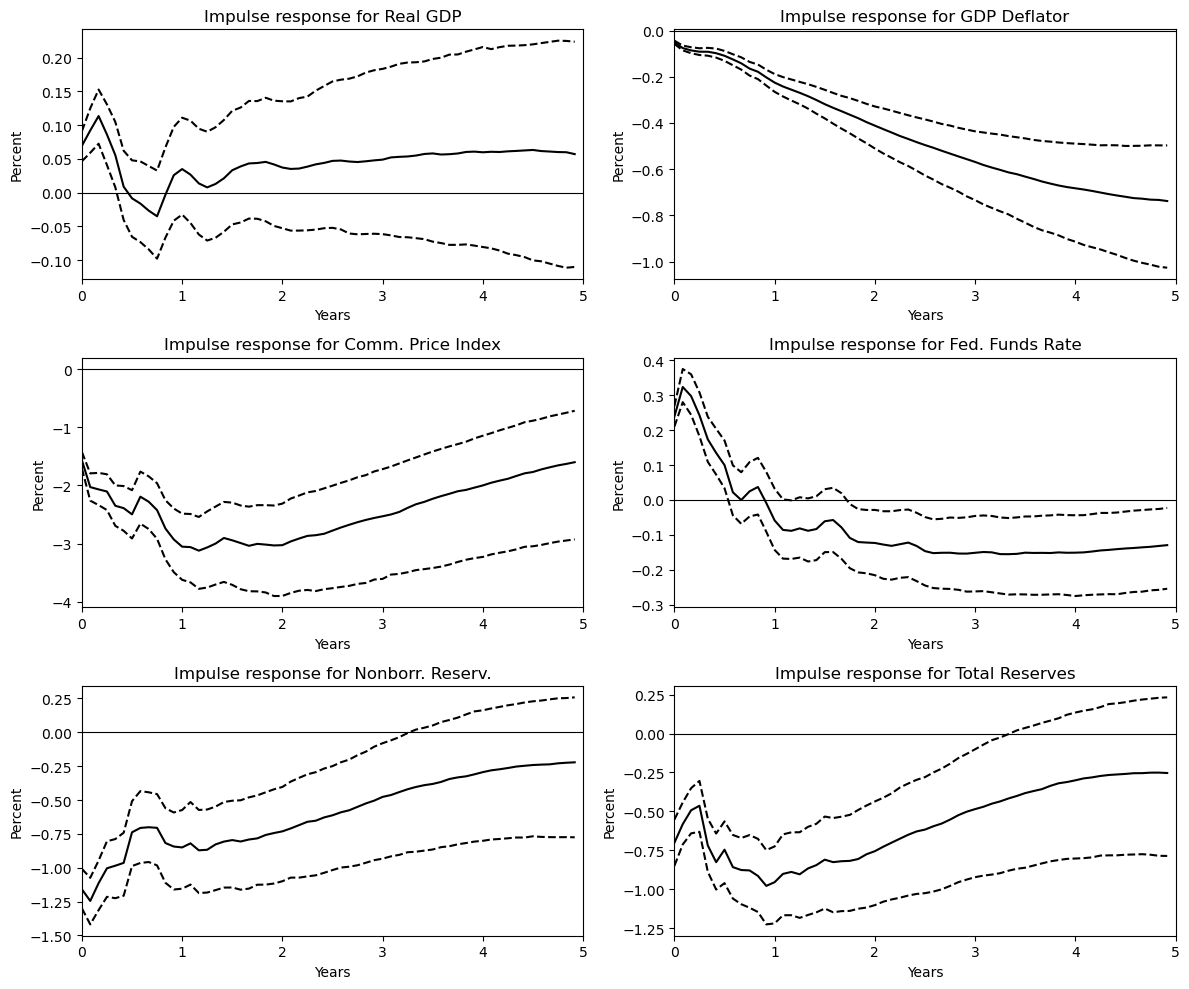

In [14]:
# ==========================================
# 5. DRAWING UHLIG'S FIG. 14 - PENALTY FUNCTION IRFS
# ==========================================
valid_irfs_penalty_arr = np.array(valid_irfs_penalty)

# ENGINEERING NOTE: Bayesian Confidence Intervals
# We extract the 16th, 50th (median), and 84th percentiles across all 
# successful Monte Carlo optimization draws to construct the standard 
# Bayesian error bands (representing roughly a one-standard-deviation coverage).
irf_16 = np.percentile(valid_irfs_penalty_arr, 16, axis=0)
irf_50 = np.percentile(valid_irfs_penalty_arr, 50, axis=0)
irf_84 = np.percentile(valid_irfs_penalty_arr, 84, axis=0)

# Variable names ordered strictly according to the VAR data frame
var_names = ['Real GDP', 'GDP Deflator', 'Comm. Price Index', 
             'Fed. Funds Rate', 'Nonborr. Reserv.', 'Total Reserves']

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

x = np.arange(n_steps)

for i in range(6):
    axes[i].plot(x, irf_50[:, i], 'k-', label='Median')
    axes[i].plot(x, irf_16[:, i], 'k--')
    axes[i].plot(x, irf_84[:, i], 'k--')
    axes[i].axhline(0, color='k', linewidth=0.8)
    axes[i].set_title(f"Impulse response for {var_names[i]}")
    
    # ENGINEERING NOTE: Visual Replication of Uhlig (2005)
    # To strictly match the formatting of Fig. 14 in the original paper, 
    # we convert the 60-month horizon on the x-axis into 5 discrete years.
    axes[i].set_xlim([0, n_steps])
    axes[i].set_xticks([0, 12, 24, 36, 48, 60])
    axes[i].set_xticklabels([0, 1, 2, 3, 4, 5])
    axes[i].set_xlabel('Years')
    axes[i].set_ylabel('Percent')

plt.tight_layout()
plt.savefig('Uhlig_Fig14_Penalty.jpg', dpi=300)
plt.show()